# DINOv3 pooling and confusion fallback experiments

基于 stage 14 导出的 crop dataset，比较三种冻结 DINOv3 线性头特征：

- `cls_mean`: 使用既有 `CLS + mean`，去掉 max pooling，避免边缘极端 patch 带跑。
- `cls_mean_max`: 复用既有 `CLS + mean + max` 384 特征缓存，作为当前 patch-aware baseline。
- `cls_mean_topk`: 重新抽取并缓存 `CLS + mean + top-k mean`，用 top-k 平均替代 raw max pooling。

同时复用 top1/top2 同组才 fallback 的 confusion group 逻辑。既有 384 `cls_mean_max` 缓存可直接复用；`cls_mean_topk` 首次运行需要抽一次 DINOv3 特征。


In [1]:
from pathlib import Path
import os
import sys
import time

matplotlib_config_dir = Path(os.environ.get("MPLCONFIGDIR", "/private/tmp/wakareeru_matplotlib"))
matplotlib_config_dir.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(matplotlib_config_dir))
font_cache_dir = Path(os.environ.get("XDG_CACHE_HOME", "/private/tmp/wakareeru_font_cache"))
font_cache_dir.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("XDG_CACHE_HOME", str(font_cache_dir))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib import font_manager
from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from transformers import AutoImageProcessor, AutoModel
from huggingface_hub import login


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists() and (path / "pipeline").exists():
            return path
    raise RuntimeError(f"Cannot find wakareeru project root from {start}")


PROJECT_ROOT = find_project_root()
for path in [PROJECT_ROOT, PROJECT_ROOT / "pipeline"]:
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

import utils


def get_torch_device(device_name: str = "auto") -> torch.device:
    if device_name == "auto":
        if torch.backends.mps.is_available():
            return torch.device("mps")
        if torch.cuda.is_available():
            return torch.device("cuda")
        return torch.device("cpu")
    return torch.device(device_name)

def configure_matplotlib_cjk() -> str | None:
    preferred_families = [
        "Hiragino Sans",
        "Hiragino Sans GB",
        "PingFang SC",
        "Noto Sans CJK JP",
        "Noto Sans CJK SC",
        "Source Han Sans JP",
        "Source Han Sans SC",
        "Yu Gothic",
        "Meiryo",
        "Arial Unicode MS",
        "Microsoft YaHei",
        "SimHei",
    ]
    available_families = set()
    for font_path in font_manager.findSystemFonts():
        try:
            available_families.add(font_manager.FontProperties(fname=font_path).get_name())
        except Exception:
            continue
    selected = next((family for family in preferred_families if family in available_families), None)
    if selected is not None:
        current = list(plt.rcParams.get("font.sans-serif", []))
        plt.rcParams["font.sans-serif"] = [selected, *[family for family in current if family != selected]]
    plt.rcParams["axes.unicode_minus"] = False
    return selected


CJK_FONT_FAMILY = configure_matplotlib_cjk()
print(f"matplotlib_cjk_font={CJK_FONT_FAMILY or 'not found'}")


config = utils.load_pipeline_config(PROJECT_ROOT / "config" / "pipeline_config.yaml")
dataset_root = utils.join_data_root(config["path"]["dataset_dir"], config=config)
metadata_path = dataset_root / config["trainer"]["metadata_file_name"]
labels_path = dataset_root / config["trainer"]["labels_file_name"]
feature_cache_dir = utils.join_data_root(config["trainer"]["feature_cache_dir"], config=config)
output_dir = dataset_root / "diagnostics" / "pooling_experiments"
output_dir.mkdir(parents=True, exist_ok=True)

print(f"project_root={PROJECT_ROOT}")
print(f"dataset_root={dataset_root}")
print(f"output_dir={output_dir}")


project_root=/Users/yukun/projects/wakareeru
dataset_root=/Users/yukun/projects/wakareeru/data/dataset
output_dir=/Users/yukun/projects/wakareeru/data/dataset/diagnostics/pooling_experiments


In [2]:
SEED = 42
IMAGE_SIZE = 384
TOPK_PATCHES = 8
NUM_WORKERS = 0
MAX_EPOCHS = 80
PATIENCE = 8
MIN_DELTA = 1e-4
HIGH_CONF_THRESHOLD = 0.8
CONFIDENCE_FALLBACK_THRESHOLD = 0.55
CONFIDENCE_ABSTAIN_THRESHOLD = 0.35

HF_MODEL_NAME = config["trainer"]["backbone_model_name"]
FEATURE_BATCH_SIZE = int(config["trainer"]["batch_size"])
HEAD_BATCH_SIZE = int(config["trainer"]["batch_size"])
LR = float(config["trainer"]["phases"][0]["learning_rate"])
WEIGHT_DECAY = float(config["trainer"]["phases"][0]["weight_decay"])
DEVICE = get_torch_device(config["trainer"]["device"])

BASE_CACHE_PATH = feature_cache_dir / "dataset_crop_dinov3_cls_mean_max_384_features.pt"
TOPK_CACHE_PATH = feature_cache_dir / f"dataset_crop_dinov3_cls_mean_topk{TOPK_PATCHES}_{IMAGE_SIZE}_features.pt"
REBUILD_TOPK_CACHE = False

CONFUSION_GROUPS = {
    "jnr_suburban_standard": ["113系", "113/115系", "115系", "165系", "415系", "455系"],
    "jnr_limited_express_standard": ["183系", "189系", "485系", "489系"],
    "jnr_kiha_standard": ["キハ40系", "キハ40/41系", "キハ47/48系", "キハ58系"],
}

ATTRIBUTE_COLUMNS = ["special_formation", "special_livery"]
ATTRIBUTE_ESCAPE_LABEL = "__none__"
ATTRIBUTE_FEATURE_VARIANT = "cls_mean"
ATTRIBUTE_USE_CLASS_WEIGHTS = True
ATTRIBUTE_PLOT_TOP_N = 24
ATTRIBUTE_SAMPLE_N = 12
ATTRIBUTE_SAMPLE_MIN_CONFIDENCE = 0.8

rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)

print(HF_MODEL_NAME, IMAGE_SIZE, DEVICE)
print(f"base_cache={BASE_CACHE_PATH}")
print(f"topk_cache={TOPK_CACHE_PATH}")


facebook/dinov3-vits16-pretrain-lvd1689m 384 mps
base_cache=/Users/yukun/projects/wakareeru/data/trainer_feature_cache/dataset_crop_dinov3_cls_mean_max_384_features.pt
topk_cache=/Users/yukun/projects/wakareeru/data/trainer_feature_cache/dataset_crop_dinov3_cls_mean_topk8_384_features.pt


In [3]:
def load_base_cache() -> dict:
    if not BASE_CACHE_PATH.exists():
        raise FileNotFoundError(f"Missing base feature cache: {BASE_CACHE_PATH}")
    cache = torch.load(BASE_CACHE_PATH, map_location="cpu", weights_only=False)
    if cache.get("model_name") != HF_MODEL_NAME:
        raise ValueError("Base cache model_name does not match trainer.backbone_model_name")
    if int(cache.get("image_size", -1)) != IMAGE_SIZE:
        raise ValueError("Base cache image_size is not 384")
    if cache.get("feature_pooling") != "cls_mean_max":
        raise ValueError("Base cache is not cls_mean_max")
    if cache["features"].shape[1] % 3 != 0:
        raise ValueError("Expected [CLS, mean, max] concatenated features")
    return cache


base_cache = load_base_cache()
hidden_size = base_cache["features"].shape[1] // 3
print("base features", tuple(base_cache["features"].shape), "hidden", hidden_size)
print("splits", pd.Series(base_cache["splits"]).value_counts().to_dict())
print("classes", len(base_cache["label_to_id"]))


base features (18012, 1152) hidden 384
splits {'train': 12608, 'val': 2702, 'test': 2702}
classes 181


## Optional top-k feature extraction

`cls_mean` 和 `cls_mean_max` 可以直接从 base cache 得到。`cls_mean_topk` 需要重新跑 DINOv3，因为 raw max pooling 不能还原 top-k patch 均值。首次运行会保存到 `TOPK_CACHE_PATH`，之后直接复用。


In [4]:
metadata = pd.read_csv(metadata_path)
labels_table = pd.read_csv(labels_path)
label_lookup = labels_table.set_index("label_id")["label"].astype(str).to_dict()
metadata["crop_id"] = metadata["image_path"].str.extract(r"_(\d+)\.").astype(int)
metadata["abs_image_path"] = metadata["image_path"].map(lambda path: dataset_root / str(path))
metadata_by_crop_id = metadata.drop_duplicates("crop_id").set_index("crop_id")


def build_frame_from_cache(cache: dict) -> pd.DataFrame:
    frame = pd.DataFrame({
        "crop_id": cache["crop_ids"].numpy(),
        "label_id_exp": cache["labels"].numpy(),
        "split": cache["splits"],
    })
    frame["label"] = frame["label_id_exp"].map(cache["id_to_label"])
    metadata_columns = ["crop_id", "image_path", "abs_image_path"] + [
        col for col in ATTRIBUTE_COLUMNS if col in metadata.columns
    ]
    frame = frame.merge(
        metadata[metadata_columns],
        on="crop_id",
        how="left",
    )
    if frame["abs_image_path"].isna().any():
        raise ValueError("Some cached crop_ids are missing from metadata.csv")
    return frame


cache_frame = build_frame_from_cache(base_cache)
print(cache_frame.shape)
display(cache_frame.groupby("split")["label"].agg(["count", "nunique"]))


(18012, 8)


,count,nunique
split,,
test,2702,177
train,12608,181
val,2702,175


In [5]:
class StoredCropDataset(torch.utils.data.Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        with Image.open(row["abs_image_path"]) as image:
            image = image.convert("RGB")
            image.load()
            return {
                "image": image.copy(),
                "crop_id": int(row["crop_id"]),
                "label_id": int(row["label_id_exp"]),
                "split": str(row["split"]),
            }


class StoredCropCollator:
    def __init__(self, processor, image_size: int):
        self.processor = processor
        self.image_size = int(image_size)

    def __call__(self, batch):
        processor_kwargs = {
            "images": [item["image"] for item in batch],
            "return_tensors": "pt",
            "size": {"height": self.image_size, "width": self.image_size},
        }
        if getattr(self.processor, "crop_size", None) is not None:
            processor_kwargs["crop_size"] = {"height": self.image_size, "width": self.image_size}
        encoded = self.processor(**processor_kwargs)
        return {
            "pixel_values": encoded["pixel_values"],
            "labels": torch.tensor([item["label_id"] for item in batch], dtype=torch.long),
            "crop_ids": torch.tensor([item["crop_id"] for item in batch], dtype=torch.long),
        }


def cls_mean_topk_features(outputs, topk_patches: int) -> torch.Tensor:
    hidden = outputs.last_hidden_state
    cls_feature = outputs.pooler_output if getattr(outputs, "pooler_output", None) is not None else hidden[:, 0]
    patch_tokens = hidden[:, 1:]
    mean_feature = patch_tokens.mean(dim=1)
    k = min(int(topk_patches), int(patch_tokens.shape[1]))
    topk_feature = patch_tokens.topk(k=k, dim=1).values.mean(dim=1)
    return torch.cat([cls_feature, mean_feature, topk_feature], dim=1)


@torch.inference_mode()
def extract_topk_cache(frame: pd.DataFrame) -> dict:
    token = os.getenv("HF_TOKEN")
    if token:
        login(token=token)
    processor = AutoImageProcessor.from_pretrained(HF_MODEL_NAME)
    model = AutoModel.from_pretrained(HF_MODEL_NAME).to(DEVICE)
    model.eval()
    dataset = StoredCropDataset(frame)
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=FEATURE_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        collate_fn=StoredCropCollator(processor, IMAGE_SIZE),
    )
    features, labels, crop_ids = [], [], []
    for batch in tqdm(loader, desc=f"extract cls_mean_topk{TOPK_PATCHES}"):
        pixel_values = batch["pixel_values"].to(DEVICE)
        outputs = model(pixel_values=pixel_values)
        features.append(cls_mean_topk_features(outputs, TOPK_PATCHES).float().cpu())
        labels.append(batch["labels"].cpu())
        crop_ids.append(batch["crop_ids"].cpu())
    return {
        "features": torch.cat(features, dim=0),
        "labels": torch.cat(labels, dim=0),
        "crop_ids": torch.cat(crop_ids, dim=0),
        "splits": frame["split"].tolist(),
        "label_to_id": base_cache["label_to_id"],
        "id_to_label": base_cache["id_to_label"],
        "raw_label_id_to_exp_id": base_cache.get("raw_label_id_to_exp_id"),
        "model_name": HF_MODEL_NAME,
        "image_size": IMAGE_SIZE,
        "feature_pooling": f"cls_mean_topk{TOPK_PATCHES}",
        "topk_patches": TOPK_PATCHES,
        "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    }


if TOPK_CACHE_PATH.exists() and not REBUILD_TOPK_CACHE:
    topk_cache = torch.load(TOPK_CACHE_PATH, map_location="cpu", weights_only=False)
    print(f"loaded topk cache: {TOPK_CACHE_PATH}")
else:
    topk_cache = extract_topk_cache(cache_frame)
    torch.save(topk_cache, TOPK_CACHE_PATH)
    print(f"saved topk cache: {TOPK_CACHE_PATH}")

print("topk features", tuple(topk_cache["features"].shape))


loaded topk cache: /Users/yukun/projects/wakareeru/data/trainer_feature_cache/dataset_crop_dinov3_cls_mean_topk8_384_features.pt
topk features (18012, 1152)


## Train and evaluate one linear head per pooling variant


In [6]:
class LinearHead(torch.nn.Module):
    def __init__(self, input_dim: int, num_classes: int):
        super().__init__()
        self.linear = torch.nn.Linear(input_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x)


class FeatureSplitDataset(torch.utils.data.Dataset):
    def __init__(self, cache: dict, split: str, features: torch.Tensor):
        split_mask = np.array(cache["splits"]) == split
        self.features = features[split_mask].float()
        self.labels = cache["labels"][split_mask].long()
        self.crop_ids = cache["crop_ids"][split_mask].long()

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx], self.crop_ids[idx]


@torch.inference_mode()
def evaluate_head(head, loader, device, desc="evaluate"):
    head.eval()
    losses, preds, labels, crop_ids, confidences, top2_preds, top2_confidences = [], [], [], [], [], [], []
    for x_cpu, y_cpu, crop_ids_cpu in tqdm(loader, desc=desc, leave=False):
        x = x_cpu.to(device)
        y = y_cpu.to(device)
        logits = head(x)
        loss = torch.nn.functional.cross_entropy(logits, y, reduction="none")
        prob = torch.softmax(logits, dim=1)
        top2 = prob.topk(k=min(2, prob.shape[1]), dim=1)
        confidence, pred = prob.max(dim=1)
        losses.append(loss.cpu())
        preds.append(pred.cpu())
        labels.append(y_cpu.cpu())
        crop_ids.append(crop_ids_cpu.cpu())
        confidences.append(confidence.cpu())
        top2_preds.append(top2.indices.cpu())
        top2_confidences.append(top2.values.cpu())
    sample_loss = torch.cat(losses).numpy()
    y_pred = torch.cat(preds).numpy()
    y_true = torch.cat(labels).numpy()
    return {
        "loss": float(sample_loss.mean()),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "sample_loss": sample_loss,
        "confidence": torch.cat(confidences).numpy(),
        "preds": y_pred,
        "labels": y_true,
        "crop_ids": torch.cat(crop_ids).numpy(),
        "top2_preds": torch.cat(top2_preds).numpy(),
        "top2_confidence": torch.cat(top2_confidences).numpy(),
    }


def make_variant_features(name: str) -> tuple[dict, torch.Tensor]:
    if name == "cls_mean":
        return base_cache, base_cache["features"][:, : hidden_size * 2]
    if name == "cls_mean_max":
        return base_cache, base_cache["features"]
    if name == f"cls_mean_topk{TOPK_PATCHES}":
        return topk_cache, topk_cache["features"]
    raise ValueError(name)


def train_variant(variant_name: str) -> tuple[pd.DataFrame, dict, dict, torch.nn.Module]:
    cache, features = make_variant_features(variant_name)
    train_ds = FeatureSplitDataset(cache, "train", features)
    val_ds = FeatureSplitDataset(cache, "val", features)
    test_ds = FeatureSplitDataset(cache, "test", features)
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=HEAD_BATCH_SIZE, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_ds, batch_size=HEAD_BATCH_SIZE, shuffle=False)
    test_loader = torch.utils.data.DataLoader(test_ds, batch_size=HEAD_BATCH_SIZE, shuffle=False)

    head = LinearHead(input_dim=int(features.shape[1]), num_classes=len(cache["label_to_id"])).to(DEVICE)
    optimizer = torch.optim.AdamW(head.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    best_val_loss = float("inf")
    best_state = None
    bad_epochs = 0
    history = []
    for epoch in tqdm(range(MAX_EPOCHS), desc=f"train {variant_name}"):
        head.train()
        running_loss = 0.0
        running_correct = 0
        running_n = 0
        for x_cpu, y_cpu, _ in tqdm(train_loader, desc=f"{variant_name} epoch {epoch}", leave=False):
            x = x_cpu.to(DEVICE)
            y = y_cpu.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = head(x)
            loss = torch.nn.functional.cross_entropy(logits, y)
            loss.backward()
            optimizer.step()
            running_loss += float(loss.detach().cpu()) * int(y.numel())
            running_correct += int(logits.argmax(dim=1).eq(y).sum().detach().cpu())
            running_n += int(y.numel())
        val_metrics = evaluate_head(head, val_loader, DEVICE, desc=f"{variant_name} val")
        row = {
            "variant": variant_name,
            "epoch": epoch,
            "train_loss": running_loss / max(1, running_n),
            "train_accuracy": running_correct / max(1, running_n),
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
        }
        history.append(row)
        print(row)
        if val_metrics["loss"] < best_val_loss - MIN_DELTA:
            best_val_loss = val_metrics["loss"]
            best_state = {k: v.detach().cpu().clone() for k, v in head.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print(f"{variant_name} early stopping at epoch={epoch}, best_val_loss={best_val_loss:.4f}")
                break
    if best_state is not None:
        head.load_state_dict(best_state)
    val_metrics = evaluate_head(head, val_loader, DEVICE, desc=f"{variant_name} final val")
    test_metrics = evaluate_head(head, test_loader, DEVICE, desc=f"{variant_name} final test")
    return pd.DataFrame(history), val_metrics, test_metrics, head


VARIANTS = ["cls_mean", "cls_mean_max", f"cls_mean_topk{TOPK_PATCHES}"]
results = {}
for variant in VARIANTS:
    history_df, val_metrics, test_metrics, head = train_variant(variant)
    history_df.to_csv(output_dir / f"{variant}_history.csv", index=False)
    results[variant] = {"history": history_df, "val": val_metrics, "test": test_metrics}

summary = pd.DataFrame([
    {
        "variant": variant,
        "val_accuracy": result["val"]["accuracy"],
        "val_loss": result["val"]["loss"],
        "test_accuracy": result["test"]["accuracy"],
        "test_loss": result["test"]["loss"],
    }
    for variant, result in results.items()
])
summary.to_csv(output_dir / "pooling_summary.csv", index=False)
display(summary)


train cls_mean:   0%|          | 0/80 [00:00<?, ?it/s]

cls_mean epoch 0:   0%|          | 0/394 [00:00<?, ?it/s]

cls_mean val:   0%|          | 0/85 [00:00<?, ?it/s]

{'variant': 'cls_mean', 'epoch': 0, 'train_loss': 2.734974794581457, 'train_accuracy': 0.43837246192893403, 'val_loss': 1.8592911958694458, 'val_accuracy': 0.6239822353811991}


cls_mean epoch 1:   0%|          | 0/394 [00:00<?, ?it/s]

...

cls_mean_topk8 val:   0%|          | 0/85 [00:00<?, ?it/s]

{'variant': 'cls_mean_topk8', 'epoch': 20, 'train_loss': 0.29237303190727526, 'train_accuracy': 0.9278236040609137, 'val_loss': 0.913689136505127, 'val_accuracy': 0.804959289415248}
cls_mean_topk8 early stopping at epoch=20, best_val_loss=0.8882


cls_mean_topk8 final val:   0%|          | 0/85 [00:00<?, ?it/s]

cls_mean_topk8 final test:   0%|          | 0/85 [00:00<?, ?it/s]

,variant,val_accuracy,val_loss,test_accuracy,test_loss
0,cls_mean,0.811991,0.851834,0.812731,0.858057
1,cls_mean_max,0.805699,0.884476,0.807920,0.901593
2,cls_mean_topk8,0.804959,0.888197,0.804589,0.909223


## Special formation and livery heads

训练额外的线性属性头，分别预测 `special_formation` 与 `special_livery`。空值统一映射到 escape category `__none__`；指标同时报告整体、非空属性样本、以及 escape 类别表现。默认复用 `ATTRIBUTE_FEATURE_VARIANT = "cls_mean"` 特征缓存。


In [7]:
attribute_output_dir = output_dir / "attribute_heads"
attribute_output_dir.mkdir(parents=True, exist_ok=True)


def clean_attribute_value(value: object) -> str:
    if pd.isna(value):
        return ATTRIBUTE_ESCAPE_LABEL
    text = str(value).strip()
    if not text or text.lower() in {"nan", "none", "null"}:
        return ATTRIBUTE_ESCAPE_LABEL
    return text


def make_attribute_features() -> tuple[dict, torch.Tensor]:
    if ATTRIBUTE_FEATURE_VARIANT == "cls_mean":
        return base_cache, base_cache["features"][:, : hidden_size * 2]
    if ATTRIBUTE_FEATURE_VARIANT == "cls_mean_max":
        return base_cache, base_cache["features"]
    if ATTRIBUTE_FEATURE_VARIANT == f"cls_mean_topk{TOPK_PATCHES}":
        if topk_cache is None:
            raise RuntimeError("Set INCLUDE_TOPK_POOLING=True and run the top-k cache cell first.")
        return topk_cache, topk_cache["features"]
    raise ValueError(f"Unsupported ATTRIBUTE_FEATURE_VARIANT: {ATTRIBUTE_FEATURE_VARIANT}")


class AttributeSplitDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        *,
        cache: dict,
        features: torch.Tensor,
        attr_labels: torch.Tensor,
        split: str,
    ):
        split_mask = np.array(cache["splits"]) == split
        self.features = features[split_mask].float()
        self.labels = attr_labels[split_mask].long()
        self.crop_ids = cache["crop_ids"][split_mask].long()

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx], self.crop_ids[idx]


@torch.inference_mode()
def evaluate_attribute_head(head, loader, device, id_to_attr_label: dict[int, str], desc="attribute eval"):
    head.eval()
    losses, preds, labels, crop_ids, confidences = [], [], [], [], []
    for x_cpu, y_cpu, crop_ids_cpu in tqdm(loader, desc=desc, leave=False):
        x = x_cpu.to(device)
        y = y_cpu.to(device)
        logits = head(x)
        loss = torch.nn.functional.cross_entropy(logits, y, reduction="none")
        prob = torch.softmax(logits, dim=1)
        confidence, pred = prob.max(dim=1)
        losses.append(loss.cpu())
        preds.append(pred.cpu())
        labels.append(y_cpu.cpu())
        crop_ids.append(crop_ids_cpu.cpu())
        confidences.append(confidence.cpu())
    sample_loss = torch.cat(losses).numpy()
    y_pred = torch.cat(preds).numpy()
    y_true = torch.cat(labels).numpy()
    pred_labels = pd.Series(y_pred).map(id_to_attr_label).to_numpy()
    true_labels = pd.Series(y_true).map(id_to_attr_label).to_numpy()
    non_escape = true_labels != ATTRIBUTE_ESCAPE_LABEL
    escape = true_labels == ATTRIBUTE_ESCAPE_LABEL
    return {
        "loss": float(sample_loss.mean()),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "non_escape_accuracy": float((pred_labels[non_escape] == true_labels[non_escape]).mean()) if non_escape.any() else np.nan,
        "escape_accuracy": float((pred_labels[escape] == true_labels[escape]).mean()) if escape.any() else np.nan,
        "non_escape_count": int(non_escape.sum()),
        "escape_count": int(escape.sum()),
        "sample_loss": sample_loss,
        "confidence": torch.cat(confidences).numpy(),
        "preds": y_pred,
        "labels": y_true,
        "pred_labels": pred_labels,
        "true_labels": true_labels,
        "crop_ids": torch.cat(crop_ids).numpy(),
    }


def make_attribute_class_weights(train_labels: torch.Tensor, num_classes: int) -> torch.Tensor | None:
    if not ATTRIBUTE_USE_CLASS_WEIGHTS:
        return None
    counts = torch.bincount(train_labels.long(), minlength=num_classes).float()
    weights = torch.ones(num_classes, dtype=torch.float32)
    seen = counts > 0
    weights[seen] = torch.sqrt(counts[seen].sum() / counts[seen]).clamp(max=20.0)
    weights[seen] = weights[seen] / weights[seen].mean().clamp(min=1e-6)
    return weights


def train_attribute_head(attribute_column: str) -> tuple[pd.DataFrame, dict, dict, pd.DataFrame]:
    if attribute_column not in cache_frame.columns:
        raise ValueError(f"metadata/cache_frame missing attribute column: {attribute_column}")
    cache, features = make_attribute_features()
    attr_values = cache_frame[attribute_column].map(clean_attribute_value)
    attr_labels = [ATTRIBUTE_ESCAPE_LABEL] + sorted(
        label for label in attr_values.unique().tolist() if label != ATTRIBUTE_ESCAPE_LABEL
    )
    attr_label_to_id = {label: idx for idx, label in enumerate(attr_labels)}
    id_to_attr_label = {idx: label for label, idx in attr_label_to_id.items()}
    attr_label_ids = torch.tensor(attr_values.map(attr_label_to_id).to_numpy(), dtype=torch.long)

    train_ds = AttributeSplitDataset(cache=cache, features=features, attr_labels=attr_label_ids, split="train")
    val_ds = AttributeSplitDataset(cache=cache, features=features, attr_labels=attr_label_ids, split="val")
    test_ds = AttributeSplitDataset(cache=cache, features=features, attr_labels=attr_label_ids, split="test")
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=HEAD_BATCH_SIZE, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_ds, batch_size=HEAD_BATCH_SIZE, shuffle=False)
    test_loader = torch.utils.data.DataLoader(test_ds, batch_size=HEAD_BATCH_SIZE, shuffle=False)

    head = LinearHead(input_dim=int(features.shape[1]), num_classes=len(attr_labels)).to(DEVICE)
    optimizer = torch.optim.AdamW(head.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    class_weights = make_attribute_class_weights(train_ds.labels, len(attr_labels))
    if class_weights is not None:
        class_weights = class_weights.to(DEVICE)
    best_val_loss = float("inf")
    best_state = None
    bad_epochs = 0
    history = []
    for epoch in tqdm(range(MAX_EPOCHS), desc=f"train {attribute_column}"):
        head.train()
        running_loss = 0.0
        running_correct = 0
        running_n = 0
        for x_cpu, y_cpu, _ in tqdm(train_loader, desc=f"{attribute_column} epoch {epoch}", leave=False):
            x = x_cpu.to(DEVICE)
            y = y_cpu.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = head(x)
            loss = torch.nn.functional.cross_entropy(logits, y, weight=class_weights)
            loss.backward()
            optimizer.step()
            running_loss += float(loss.detach().cpu()) * int(y.numel())
            running_correct += int(logits.argmax(dim=1).eq(y).sum().detach().cpu())
            running_n += int(y.numel())
        val_metrics = evaluate_attribute_head(
            head,
            val_loader,
            DEVICE,
            id_to_attr_label,
            desc=f"{attribute_column} val",
        )
        row = {
            "attribute": attribute_column,
            "epoch": epoch,
            "train_loss": running_loss / max(1, running_n),
            "train_accuracy": running_correct / max(1, running_n),
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_non_escape_accuracy": val_metrics["non_escape_accuracy"],
            "val_escape_accuracy": val_metrics["escape_accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
        }
        history.append(row)
        print(row)
        if val_metrics["loss"] < best_val_loss - MIN_DELTA:
            best_val_loss = val_metrics["loss"]
            best_state = {k: v.detach().cpu().clone() for k, v in head.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print(f"{attribute_column} early stopping at epoch={epoch}, best_val_loss={best_val_loss:.4f}")
                break
    if best_state is not None:
        head.load_state_dict(best_state)

    val_metrics = evaluate_attribute_head(head, val_loader, DEVICE, id_to_attr_label, desc=f"{attribute_column} final val")
    test_metrics = evaluate_attribute_head(head, test_loader, DEVICE, id_to_attr_label, desc=f"{attribute_column} final test")

    predictions = []
    for split_name, metrics in [("val", val_metrics), ("test", test_metrics)]:
        frame = pd.DataFrame({
            "crop_id": metrics["crop_ids"],
            "true_attribute": metrics["true_labels"],
            "pred_attribute": metrics["pred_labels"],
            "confidence": metrics["confidence"],
            "loss": metrics["sample_loss"],
            "split": split_name,
            "attribute": attribute_column,
        })
        frame["correct"] = frame["true_attribute"] == frame["pred_attribute"]
        frame = frame.merge(cache_frame[["crop_id", "image_path", "abs_image_path", "label"]], on="crop_id", how="left")
        predictions.append(frame)
    prediction_df = pd.concat(predictions, ignore_index=True)

    label_counts = (
        pd.DataFrame({"attribute_label": attr_values, "split": cache_frame["split"]})
        .groupby(["attribute_label", "split"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    label_counts.to_csv(attribute_output_dir / f"{attribute_column}_label_counts.csv", index=False)
    pd.DataFrame(history).to_csv(attribute_output_dir / f"{attribute_column}_history.csv", index=False)
    prediction_df.to_csv(attribute_output_dir / f"{attribute_column}_predictions.csv", index=False)
    return pd.DataFrame(history), val_metrics, test_metrics, prediction_df


attribute_results = {}
for attribute_column in ATTRIBUTE_COLUMNS:
    history_df, val_metrics, test_metrics, prediction_df = train_attribute_head(attribute_column)
    attribute_results[attribute_column] = {
        "history": history_df,
        "val": val_metrics,
        "test": test_metrics,
        "predictions": prediction_df,
    }

attribute_summary = pd.DataFrame([
    {
        "attribute": attribute,
        "val_accuracy": result["val"]["accuracy"],
        "val_non_escape_accuracy": result["val"]["non_escape_accuracy"],
        "val_escape_accuracy": result["val"]["escape_accuracy"],
        "val_macro_f1": result["val"]["macro_f1"],
        "val_non_escape_count": result["val"]["non_escape_count"],
        "test_accuracy": result["test"]["accuracy"],
        "test_non_escape_accuracy": result["test"]["non_escape_accuracy"],
        "test_escape_accuracy": result["test"]["escape_accuracy"],
        "test_macro_f1": result["test"]["macro_f1"],
        "test_non_escape_count": result["test"]["non_escape_count"],
        "feature_variant": ATTRIBUTE_FEATURE_VARIANT,
        "escape_label": ATTRIBUTE_ESCAPE_LABEL,
    }
    for attribute, result in attribute_results.items()
])
attribute_summary.to_csv(attribute_output_dir / "attribute_summary.csv", index=False)
display(attribute_summary)



train special_formation:   0%|          | 0/80 [00:00<?, ?it/s]

special_formation epoch 0:   0%|          | 0/394 [00:00<?, ?it/s]

special_formation val:   0%|          | 0/85 [00:00<?, ?it/s]

{'attribute': 'special_formation', 'epoch': 0, 'train_loss': 2.296875791198711, 'train_accuracy': 0.930123730964467, 'val_loss': 0.6990712881088257, 'val_accuracy': 0.9400444115470022, 'val_non_escape_accuracy': 0.14545454545454545, 'val_escape_accuracy': 0.991722506897911, 'val_macro_f1': 0.08184345990759893}


special_formation epoch 1:   0%|          | 0/394 [00:00<?, ?it/s]

...

special_livery val:   0%|          | 0/85 [00:00<?, ?it/s]

{'attribute': 'special_livery', 'epoch': 23, 'train_loss': 0.3226734926631003, 'train_accuracy': 0.8533470812182741, 'val_loss': 0.7687574625015259, 'val_accuracy': 0.7823834196891192, 'val_non_escape_accuracy': 0.6694078947368421, 'val_escape_accuracy': 0.8151862464183381, 'val_macro_f1': 0.4485639196431318}
special_livery early stopping at epoch=23, best_val_loss=0.7262


special_livery final val:   0%|          | 0/85 [00:00<?, ?it/s]

special_livery final test:   0%|          | 0/85 [00:00<?, ?it/s]

,attribute,val_accuracy,val_non_escape_accuracy,val_escape_accuracy,val_macro_f1,val_non_escape_count,test_accuracy,test_non_escape_accuracy,test_escape_accuracy,test_macro_f1,test_non_escape_count,feature_variant,escape_label
0,special_formation,0.961510,0.527273,0.989752,0.482445,165,0.956699,0.547486,0.985731,0.515073,179,cls_mean,__none__
1,special_livery,0.790896,0.675987,0.824260,0.472035,608,0.792006,0.643678,0.835165,0.473206,609,cls_mean,__none__


## Attribute head visual diagnostics


In [ ]:
def get_attribute_result_frames(attribute_column: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    summary_path = attribute_output_dir / "attribute_summary.csv"
    counts_path = attribute_output_dir / f"{attribute_column}_label_counts.csv"
    predictions_path = attribute_output_dir / f"{attribute_column}_predictions.csv"
    if "attribute_summary" in globals():
        summary_df = attribute_summary.copy()
    elif summary_path.exists():
        summary_df = pd.read_csv(summary_path)
    else:
        summary_df = pd.DataFrame()
    if "attribute_results" in globals() and attribute_column in attribute_results:
        predictions_df = attribute_results[attribute_column]["predictions"].copy()
    elif predictions_path.exists():
        predictions_df = pd.read_csv(predictions_path)
    else:
        raise FileNotFoundError(f"Run the attribute head cell first or create {predictions_path}")
    if counts_path.exists():
        counts_df = pd.read_csv(counts_path)
    else:
        raise FileNotFoundError(f"Run the attribute head cell first or create {counts_path}")
    if "abs_image_path" not in predictions_df.columns:
        predictions_df = predictions_df.merge(
            cache_frame[["crop_id", "abs_image_path"]],
            on="crop_id",
            how="left",
        )
    return summary_df, counts_df, predictions_df


def plot_attribute_summary(summary_df: pd.DataFrame | None = None):
    if summary_df is None:
        summary_path = attribute_output_dir / "attribute_summary.csv"
        summary_df = attribute_summary.copy() if "attribute_summary" in globals() else pd.read_csv(summary_path)
    metrics = [
        "val_accuracy",
        "val_non_escape_accuracy",
        "val_escape_accuracy",
        "val_macro_f1",
        "test_accuracy",
        "test_non_escape_accuracy",
        "test_escape_accuracy",
        "test_macro_f1",
    ]
    available = [metric for metric in metrics if metric in summary_df.columns]
    plot_df = summary_df.set_index("attribute")[available]
    ax = plot_df.T.plot(kind="bar", figsize=(12, 4), ylim=(0, 1), rot=35)
    ax.set_ylabel("score")
    ax.set_title("Attribute head metrics")
    ax.legend(title="attribute", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_attribute_label_counts(attribute_column: str, top_n: int = ATTRIBUTE_PLOT_TOP_N):
    _, counts_df, _ = get_attribute_result_frames(attribute_column)
    split_columns = [col for col in ["train", "val", "test"] if col in counts_df.columns]
    counts_df = counts_df.copy()
    counts_df["total"] = counts_df[split_columns].sum(axis=1)
    plot_df = counts_df.nlargest(top_n, "total").sort_values("total")
    fig_height = max(4, min(12, 0.35 * len(plot_df)))
    fig, ax = plt.subplots(figsize=(12, fig_height))
    left = np.zeros(len(plot_df))
    y = np.arange(len(plot_df))
    for split in split_columns:
        values = plot_df[split].to_numpy()
        ax.barh(y, values, left=left, label=split)
        left += values
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["attribute_label"])
    ax.set_xlabel("samples")
    ax.set_title(f"{attribute_column} label distribution, top {len(plot_df)}")
    ax.legend()
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_attribute_confusion(attribute_column: str, split: str = "test", top_n: int = 18):
    _, _, predictions_df = get_attribute_result_frames(attribute_column)
    frame = predictions_df.query("split == @split").copy()
    if frame.empty:
        raise ValueError(f"No predictions for split={split}")
    true_counts = frame["true_attribute"].value_counts()
    labels = true_counts.head(top_n).index.tolist()
    for label in [ATTRIBUTE_ESCAPE_LABEL, *frame.loc[~frame["correct"], "pred_attribute"].value_counts().head(4).index.tolist()]:
        if label in frame["true_attribute"].values or label in frame["pred_attribute"].values:
            if label not in labels:
                labels.append(label)
    matrix = confusion_matrix(frame["true_attribute"], frame["pred_attribute"], labels=labels)
    row_sums = matrix.sum(axis=1, keepdims=True).clip(min=1)
    norm_matrix = matrix / row_sums
    fig_size = max(6, min(14, 0.55 * len(labels)))
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    im = ax.imshow(norm_matrix, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=60, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(f"{attribute_column} normalized confusion ({split})")
    for i in range(len(labels)):
        for j in range(len(labels)):
            count = matrix[i, j]
            if count:
                ax.text(j, i, str(count), ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


In [ ]:
def select_attribute_samples(
    attribute_column: str,
    *,
    split: str = "test",
    mode: str = "high_conf_wrong",
    n: int = ATTRIBUTE_SAMPLE_N,
    min_confidence: float = ATTRIBUTE_SAMPLE_MIN_CONFIDENCE,
    random_state: int = SEED,
) -> pd.DataFrame:
    _, _, predictions_df = get_attribute_result_frames(attribute_column)
    frame = predictions_df.query("split == @split").copy()
    if mode == "high_conf_wrong":
        frame = frame[(~frame["correct"]) & (frame["confidence"] >= min_confidence)]
        frame = frame.sort_values("confidence", ascending=False)
    elif mode == "missed_attribute":
        frame = frame[(frame["true_attribute"] != ATTRIBUTE_ESCAPE_LABEL) & (frame["pred_attribute"] == ATTRIBUTE_ESCAPE_LABEL)]
        frame = frame.sort_values("confidence", ascending=False)
    elif mode == "false_positive_attribute":
        frame = frame[(frame["true_attribute"] == ATTRIBUTE_ESCAPE_LABEL) & (frame["pred_attribute"] != ATTRIBUTE_ESCAPE_LABEL)]
        frame = frame.sort_values("confidence", ascending=False)
    elif mode == "correct_non_escape":
        frame = frame[(frame["true_attribute"] != ATTRIBUTE_ESCAPE_LABEL) & frame["correct"]]
        frame = frame.sample(min(n, len(frame)), random_state=random_state) if len(frame) else frame
    elif mode == "wrong_non_escape":
        frame = frame[(frame["true_attribute"] != ATTRIBUTE_ESCAPE_LABEL) & (~frame["correct"])]
        frame = frame.sort_values("confidence", ascending=False)
    else:
        raise ValueError(
            "mode must be one of: high_conf_wrong, missed_attribute, false_positive_attribute, "
            "correct_non_escape, wrong_non_escape"
        )
    return frame.head(n).reset_index(drop=True)


def show_attribute_samples(sample_df: pd.DataFrame, *, title: str | None = None, ncols: int = 4):
    if sample_df.empty:
        print("No samples matched this query.")
        return
    n = len(sample_df)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.4 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax in axes[n:]:
        ax.axis("off")
    for ax, (_, row) in zip(axes, sample_df.iterrows()):
        image_path = Path(row["abs_image_path"])
        if not image_path.is_absolute():
            image_path = dataset_root / row["image_path"]
        try:
            with Image.open(image_path) as image:
                ax.imshow(image.convert("RGB"))
        except Exception as exc:
            ax.text(0.5, 0.5, f"image load failed\n{exc}", ha="center", va="center", wrap=True)
        ax.axis("off")
        subtitle = (
            f"{row.get('label', '')} | conf={row['confidence']:.2f}\n"
            f"true: {row['true_attribute']}\n"
            f"pred: {row['pred_attribute']}"
        )
        ax.set_title(subtitle, fontsize=9)
    if title:
        fig.suptitle(title, y=1.01, fontsize=13)
    plt.tight_layout()
    plt.show()


def show_attribute_diagnostics(attribute_column: str, split: str = "test"):
    summary_df, _, _ = get_attribute_result_frames(attribute_column)
    display(summary_df.query("attribute == @attribute_column"))
    plot_attribute_label_counts(attribute_column)
    plot_attribute_confusion(attribute_column, split=split)
    for mode in ["high_conf_wrong", "missed_attribute", "false_positive_attribute", "correct_non_escape"]:
        samples = select_attribute_samples(attribute_column, split=split, mode=mode)
        show_attribute_samples(samples, title=f"{attribute_column} / {split} / {mode}")


In [ ]:
plot_attribute_summary()
for attribute_column in ATTRIBUTE_COLUMNS:
    show_attribute_diagnostics(attribute_column, split="test")


## Confusion fallback diagnostics


In [8]:
def confusion_group_for_label(label: str) -> str | None:
    label = str(label)
    for group_name, members in CONFUSION_GROUPS.items():
        if any(member in label for member in members):
            return group_name
    return None


def top2_shared_confusion_group(pred_label: str, top2_label: str) -> str | None:
    pred_group = confusion_group_for_label(pred_label)
    top2_group = confusion_group_for_label(top2_label)
    if pred_group is not None and pred_group == top2_group:
        return pred_group
    return None


def fallback_label_for_prediction(pred_label: str, top2_label: str, confidence: float, threshold: float) -> str:
    group = top2_shared_confusion_group(pred_label, top2_label)
    if group is not None and confidence < threshold:
        return group
    return pred_label


def output_matches(row: pd.Series, output_col: str) -> bool:
    output_label = row[output_col]
    if output_label == "__abstain__":
        return False
    if output_label in CONFUSION_GROUPS:
        return output_label == row["true_confusion_group"]
    return output_label == row["true_label"]


def build_prediction_frame(metrics: dict, split_name: str, variant_name: str) -> pd.DataFrame:
    result = pd.DataFrame({
        "crop_id": metrics["crop_ids"],
        "label_id": metrics["labels"],
        "pred_id": metrics["preds"],
        "confidence": metrics["confidence"],
        "loss": metrics["sample_loss"],
        "top1_id": metrics["top2_preds"][:, 0],
        "top1_confidence": metrics["top2_confidence"][:, 0],
        "top2_id": metrics["top2_preds"][:, 1] if metrics["top2_preds"].shape[1] > 1 else -1,
        "top2_confidence": metrics["top2_confidence"][:, 1] if metrics["top2_confidence"].shape[1] > 1 else 0.0,
    })
    result["true_label"] = result["label_id"].map(base_cache["id_to_label"])
    result["pred_label"] = result["pred_id"].map(base_cache["id_to_label"])
    result["top2_label"] = result["top2_id"].map(base_cache["id_to_label"]).fillna("")
    result["correct"] = result["label_id"] == result["pred_id"]
    result["true_confusion_group"] = result["true_label"].map(confusion_group_for_label)
    result["pred_confusion_group"] = result["pred_label"].map(confusion_group_for_label)
    result["top2_confusion_group"] = result["top2_label"].map(confusion_group_for_label)
    result["fallback_candidate_group"] = result.apply(
        lambda row: top2_shared_confusion_group(row["pred_label"], row["top2_label"]),
        axis=1,
    )
    result["fallback_label"] = result.apply(
        lambda row: fallback_label_for_prediction(row["pred_label"], row["top2_label"], row["confidence"], CONFIDENCE_FALLBACK_THRESHOLD),
        axis=1,
    )
    result["fallback_correct"] = result.apply(lambda row: output_matches(row, "fallback_label"), axis=1)
    result["split"] = split_name
    result["variant"] = variant_name
    result = result.merge(cache_frame[["crop_id", "image_path"]], on="crop_id", how="left")
    return result


def threshold_sweep(result_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for threshold in np.round(np.arange(0.1, 0.91, 0.05), 2):
        tmp = result_df.copy()
        tmp["sweep_fallback_label"] = tmp.apply(
            lambda row: fallback_label_for_prediction(row["pred_label"], row["top2_label"], row["confidence"], float(threshold)),
            axis=1,
        )
        tmp["sweep_fallback_correct"] = tmp.apply(lambda row: output_matches(row, "sweep_fallback_label"), axis=1)
        changed = tmp["sweep_fallback_label"] != tmp["pred_label"]
        output_group = tmp["sweep_fallback_label"].isin(CONFUSION_GROUPS)
        rows.append({
            "variant": str(result_df["variant"].iloc[0]),
            "split": str(result_df["split"].iloc[0]),
            "threshold": float(threshold),
            "fallback_accuracy": float(tmp["sweep_fallback_correct"].mean()),
            "changed_rate": float(changed.mean()),
            "changed_accuracy": float(tmp.loc[changed, "sweep_fallback_correct"].mean()) if changed.any() else np.nan,
            "group_output_rate": float(output_group.mean()),
            "group_output_precision": float(tmp.loc[output_group, "sweep_fallback_correct"].mean()) if output_group.any() else np.nan,
        })
    return pd.DataFrame(rows)


prediction_frames = []
sweep_frames = []
high_conf_wrong_frames = []
for variant, result in results.items():
    for split_name in ["val", "test"]:
        pred_df = build_prediction_frame(result[split_name], split_name, variant)
        pred_df.to_csv(output_dir / f"{variant}_{split_name}_predictions.csv", index=False)
        prediction_frames.append(pred_df)
        sweep_frames.append(threshold_sweep(pred_df))
        high_conf = pred_df.loc[
            ~pred_df["correct"] & (pred_df["confidence"] >= HIGH_CONF_THRESHOLD),
            ["variant", "split", "crop_id", "image_path", "true_label", "pred_label", "top2_label", "confidence", "loss", "true_confusion_group", "pred_confusion_group", "top2_confusion_group"],
        ].sort_values(["confidence", "loss"], ascending=[False, False])
        high_conf.to_csv(output_dir / f"{variant}_{split_name}_high_conf_wrong.csv", index=False)
        high_conf_wrong_frames.append(high_conf)

all_predictions = pd.concat(prediction_frames, ignore_index=True)
fallback_sweep = pd.concat(sweep_frames, ignore_index=True)
high_conf_wrong = pd.concat(high_conf_wrong_frames, ignore_index=True)

fallback_summary = (
    all_predictions.groupby(["variant", "split"])
    .apply(lambda g: pd.Series({
        "plain_accuracy": g["correct"].mean(),
        "fallback_accuracy": g["fallback_correct"].mean(),
        "fallback_changed_rate": (g["fallback_label"] != g["pred_label"]).mean(),
        "fallback_changed_accuracy": g.loc[g["fallback_label"] != g["pred_label"], "fallback_correct"].mean(),
        "high_conf_wrong_count": ((~g["correct"]) & (g["confidence"] >= HIGH_CONF_THRESHOLD)).sum(),
    }))
    .reset_index()
)

all_predictions.to_csv(output_dir / "all_predictions.csv", index=False)
fallback_sweep.to_csv(output_dir / "fallback_threshold_sweep.csv", index=False)
fallback_summary.to_csv(output_dir / "fallback_summary.csv", index=False)
high_conf_wrong.to_csv(output_dir / "high_conf_wrong_all.csv", index=False)

display(fallback_summary)
display(fallback_sweep.query("split == 'val' and threshold in [0.55, 0.7, 0.85]").sort_values(["variant", "threshold"]))
display(high_conf_wrong.groupby(["variant", "split"]).size().rename("high_conf_wrong_count").reset_index())


/var/folders/h4/flmszp1906l3vn21tj84nvrr0000gn/T/ipykernel_48652/4084597499.py:113: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,variant,split,plain_accuracy,fallback_accuracy,fallback_changed_rate,fallback_changed_accuracy,high_conf_wrong_count
0,cls_mean,test,0.812731,0.820133,0.021095,0.859649,108.0
1,cls_mean,val,0.811991,0.821984,0.023316,0.920635,107.0
2,cls_mean_max,test,0.807920,0.814582,0.022576,0.885246,121.0
3,cls_mean_max,val,0.805699,0.813842,0.024796,0.910448,118.0
4,cls_mean_topk8,test,0.804589,0.815692,0.024056,0.876923,99.0
5,cls_mean_topk8,val,0.804959,0.815692,0.027387,0.878378,89.0


,variant,split,threshold,fallback_accuracy,changed_rate,changed_accuracy,group_output_rate,group_output_precision
9,cls_mean,val,0.55,0.821984,0.023316,0.920635,0.023316,0.920635
12,cls_mean,val,0.70,0.829756,0.043301,0.923077,0.043301,0.923077
15,cls_mean,val,0.85,0.834937,0.065507,0.920904,0.065507,0.920904
43,cls_mean_max,val,0.55,0.813842,0.024796,0.910448,0.024796,0.910448
46,cls_mean_max,val,0.70,0.821984,0.051073,0.949275,0.051073,0.949275
49,cls_mean_max,val,0.85,0.827535,0.074019,0.935000,0.074019,0.935000
77,cls_mean_topk8,val,0.55,0.815692,0.027387,0.878378,0.027387,0.878378
80,cls_mean_topk8,val,0.70,0.825315,0.054034,0.897260,0.054034,0.897260
83,cls_mean_topk8,val,0.85,0.828645,0.082902,0.897321,0.082902,0.897321


,variant,split,high_conf_wrong_count
0,cls_mean,test,108
1,cls_mean,val,107
2,cls_mean_max,test,121
3,cls_mean_max,val,118
4,cls_mean_topk8,test,99
5,cls_mean_topk8,val,89


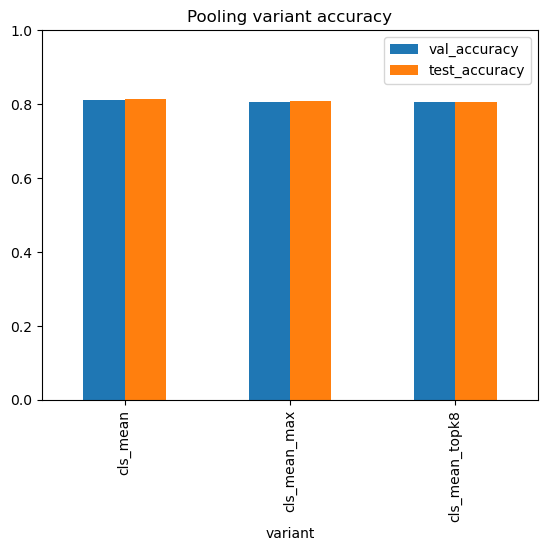

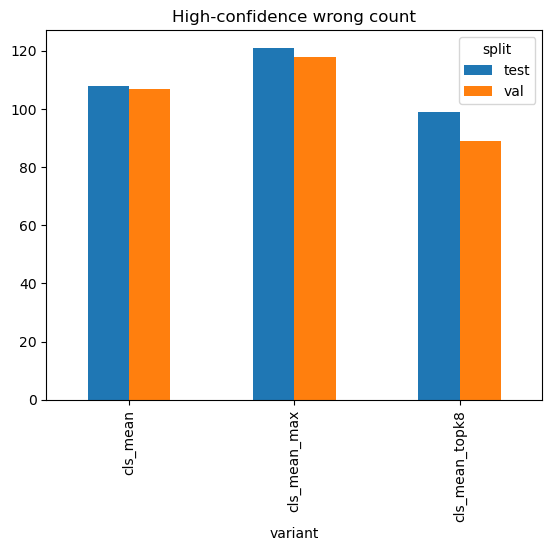

In [9]:
import matplotlib.pyplot as plt

summary.set_index("variant")[["val_accuracy", "test_accuracy"]].plot(kind="bar", title="Pooling variant accuracy")
plt.ylim(0, 1)
plt.show()

fallback_summary.pivot(index="variant", columns="split", values="high_conf_wrong_count").plot(kind="bar", title="High-confidence wrong count")
plt.show()
